In [56]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\practice\Fraud_Detection_Analysis\experiments\Bank_Transaction_Fraud_Detection.csv")

df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

In [58]:
df.shape

(200000, 24)

In [59]:
df['Transaction_Description'].nunique()

172

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

In [61]:
df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [62]:
drop_cols = [
    "Customer_ID",
    "Customer_Name",
    "Transaction_ID",
    "Customer_Contact",
    "Customer_Email",
    "Merchant_ID",
    "Transaction_Description",
    "Transaction_Currency"
]

df = df.drop(columns=drop_cols)

In [63]:
df["Is_Fraud"].value_counts()

Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

In [64]:
df["Is_Fraud"].value_counts(normalize=True)

Is_Fraud
0    0.94956
1    0.05044
Name: proportion, dtype: float64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Date      200000 non-null  object 
 7   Transaction_Time      200000 non-null  object 
 8   Transaction_Amount    200000 non-null  float64
 9   Transaction_Type      200000 non-null  object 
 10  Merchant_Category     200000 non-null  object 
 11  Account_Balance       200000 non-null  float64
 12  Transaction_Device    200000 non-null  object 
 13  Transaction_Location  200000 non-null  object 
 14  Device_Type           200000 non-null  object 
 15  

In [66]:
# Convert date
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day

# Convert time
df['Hour'] = pd.to_datetime(df['Transaction_Time']).dt.hour

# Drop original columns
df.drop(['Transaction_Date', 'Transaction_Time'], axis=1, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14296\1590027535.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14296\1590027535.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Transaction_Time']).dt.hour


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  object 
 8   Merchant_Category     200000 non-null  object 
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  object 
 11  Transaction_Location  200000 non-null  object 
 12  Device_Type           200000 non-null  object 
 13  Is_Fraud              200000 non-null  int64  
 14  Year                  200000 non-null  int32  
 15  

In [68]:
# nominal_cols = [
#     'Gender',
#     'State',
#     'Account_Type',
#     'Transaction_Type',
#     'Merchant_Category',
#     'Transaction_Device',
#     'Device_Type',

# ]

# df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'City',
    'Bank_Branch',
    'Transaction_Location',
    'Gender',
    'State',
    'Account_Type',
    'Transaction_Type',
    'Merchant_Category',
    'Transaction_Device',
    'Device_Type',
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [70]:
df

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Year,Month,Day,Hour
0,1,60,15,127,127,2,32415.45,3,5,74557.27,17,129,3,0,2025,1,23,16
1,0,51,18,100,100,0,43622.60,0,5,74622.66,9,102,1,0,2025,1,11,17
2,1,20,4,13,13,2,63062.56,0,3,66817.99,0,13,1,0,2025,1,25,3
3,0,57,28,22,22,0,14000.72,2,2,58177.08,8,24,2,0,2025,1,19,12
4,0,43,25,7,7,2,18335.16,3,2,16108.56,16,7,2,0,2025,1,30,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,0,55,7,33,33,0,98513.74,1,5,37475.11,6,35,0,0,2025,1,8,18
199996,1,51,19,63,63,0,40593.55,4,3,53037.20,0,65,0,0,2025,1,1,20
199997,0,41,5,21,21,2,61579.70,4,4,96225.36,0,21,1,0,2025,1,28,10
199998,0,28,29,103,103,1,39488.22,2,1,89599.90,17,105,1,0,2025,1,8,6


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  int64  
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  int64  
 3   City                  200000 non-null  int64  
 4   Bank_Branch           200000 non-null  int64  
 5   Account_Type          200000 non-null  int64  
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  int64  
 8   Merchant_Category     200000 non-null  int64  
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  int64  
 11  Transaction_Location  200000 non-null  int64  
 12  Device_Type           200000 non-null  int64  
 13  Is_Fraud              200000 non-null  int64  
 14  Year                  200000 non-null  int32  
 15  

In [84]:
legit = df[df.Is_Fraud==0]
fraud = df[df.Is_Fraud==1]

In [87]:
X = legit.sample(n=10088)
new_dataset = pd.concat([X,fraud],axis=0)

In [88]:
new_dataset.head()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Year,Month,Day,Hour
156521,0,69,28,22,22,0,23344.56,4,2,45495.28,13,24,3,0,2025,1,12,2
128137,1,59,21,72,72,2,3802.60,1,5,14114.59,10,74,3,0,2025,1,20,21
167734,1,42,0,31,31,2,28952.37,1,1,85525.84,15,33,0,0,2025,1,17,15
195733,0,62,1,129,129,2,27520.48,0,1,43725.22,4,131,0,0,2025,1,29,21
58275,1,51,24,143,143,1,31729.27,4,0,91791.67,1,146,3,0,2025,1,3,17


In [91]:
new_dataset.groupby('Is_Fraud').mean()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Year,Month,Day,Hour
Is_Fraud,,,,,,,,,,,,,,,,,
0,0.499703,44.063144,16.622621,70.827220,70.827220,1.005056,49431.478969,1.999703,2.517149,52526.721852,8.539849,72.586538,1.513382,2025.0,1.0,15.480868,11.399782
1,0.503668,43.914453,16.776467,71.212926,71.212926,0.991376,49277.925242,2.000099,2.489592,52452.891412,8.601308,72.968577,1.499703,2025.0,1.0,15.510904,11.431602


In [92]:
corr = new_dataset.corr(numeric_only=True)

print(
    corr['Is_Fraud']
    .sort_values(
        key=abs,
        ascending=False
    )
)

Is_Fraud                1.000000
Account_Type           -0.008359
Merchant_Category      -0.008042
State                   0.007874
Device_Type            -0.006111
Transaction_Device      0.005025
Age                    -0.004877
City                    0.004615
Bank_Branch             0.004615
Transaction_Location    0.004508
Gender                  0.003965
Transaction_Amount     -0.002677
Hour                    0.002304
Day                     0.001721
Account_Balance        -0.001353
Transaction_Type        0.000141
Year                         NaN
Month                        NaN
Name: Is_Fraud, dtype: float64


In [76]:
X = new_dataset.drop('Is_Fraud', axis=1)
y = new_dataset['Is_Fraud']

In [77]:
X.shape
y.shape

(20176,)

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

In [79]:
import matplotlib.pyplot as plt 
import seaborn as sns

2026-06-09 21:23:26,401 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-09 21:23:26,426 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


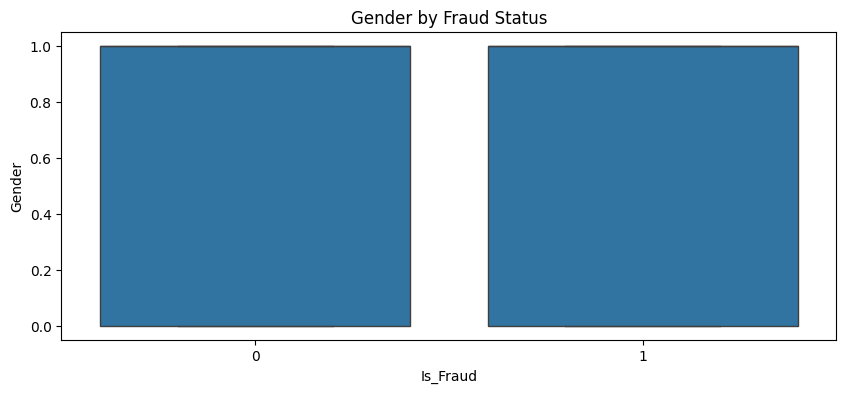

2026-06-09 21:23:26,542 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:26,559 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


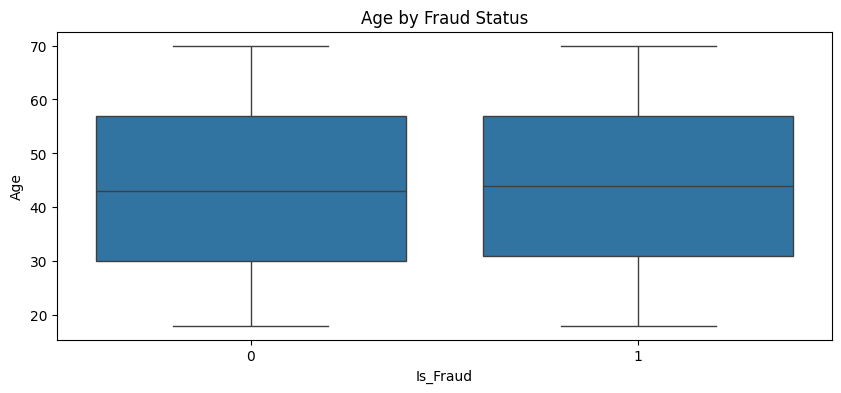

2026-06-09 21:23:26,683 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:26,700 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


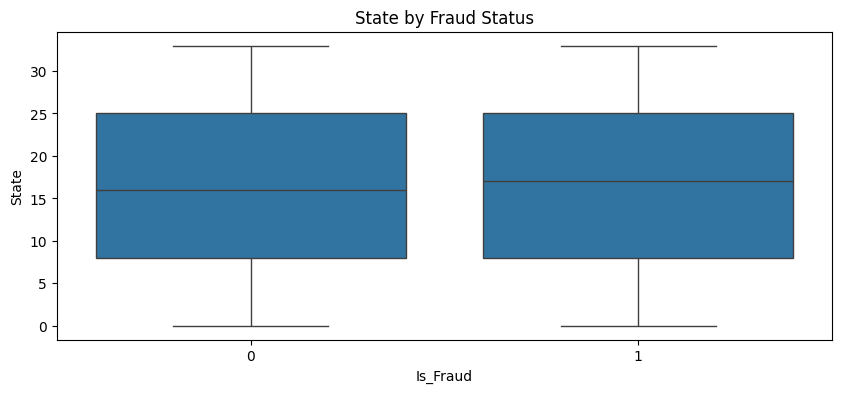

2026-06-09 21:23:26,793 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:26,813 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


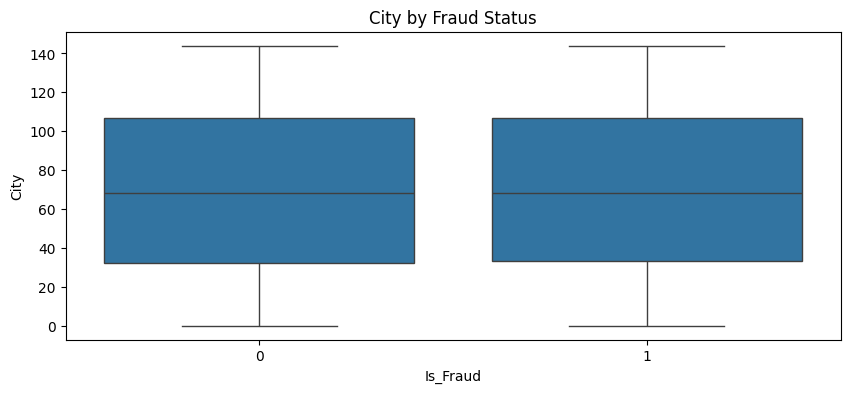

2026-06-09 21:23:26,939 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:26,960 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


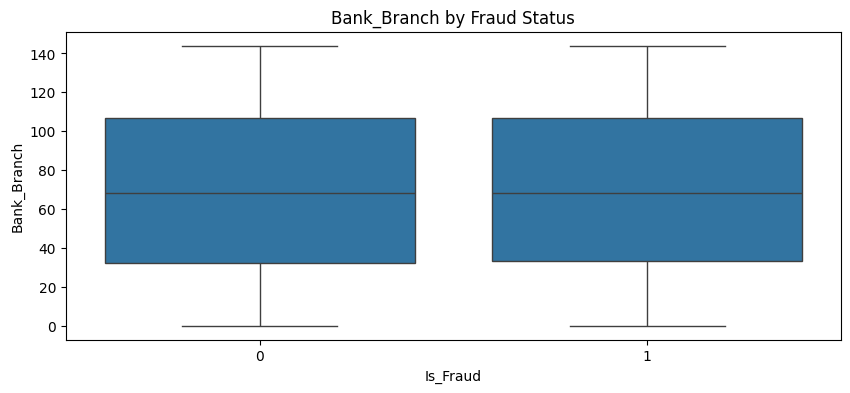

2026-06-09 21:23:27,087 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:27,113 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


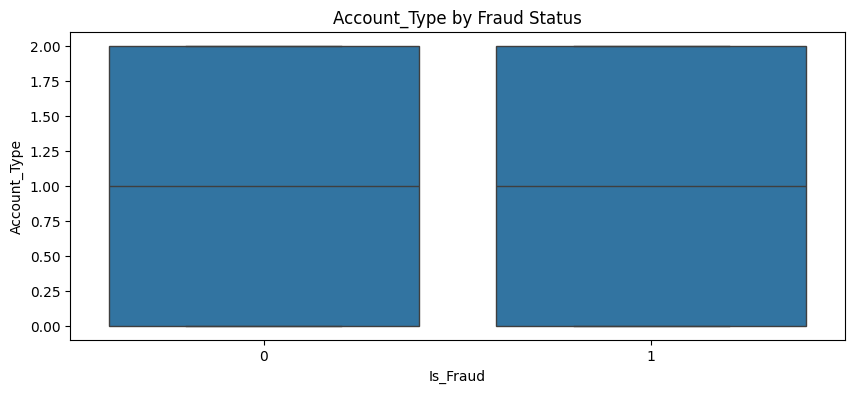

2026-06-09 21:23:27,353 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:27,379 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


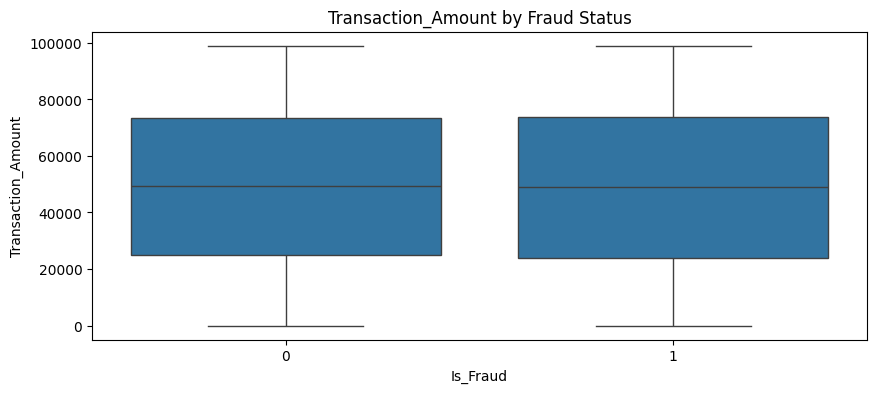

2026-06-09 21:23:27,545 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:27,555 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


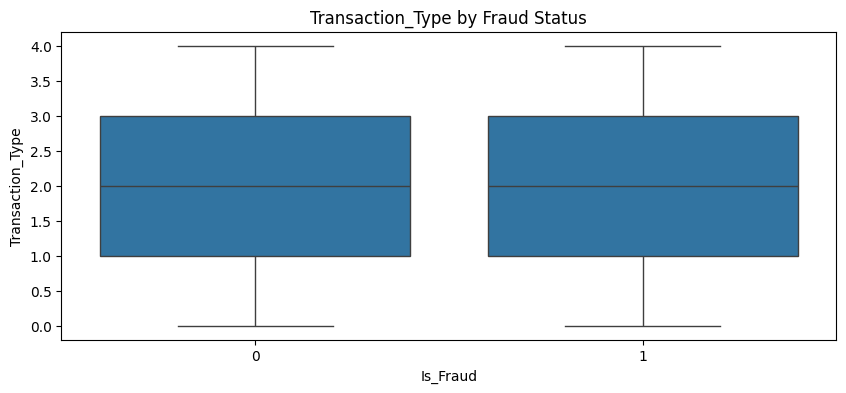

2026-06-09 21:23:27,693 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:27,721 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


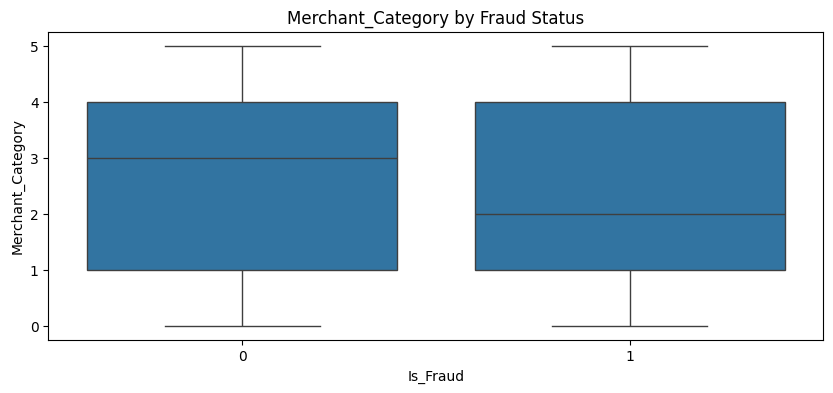

2026-06-09 21:23:27,971 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:27,994 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


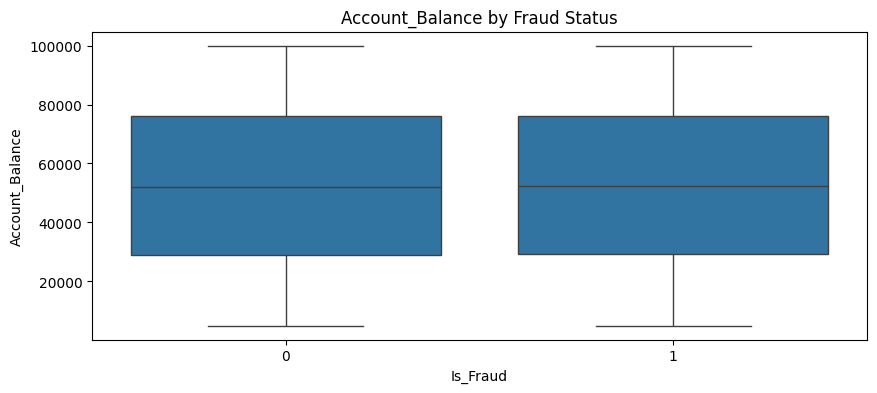

2026-06-09 21:23:28,146 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,167 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


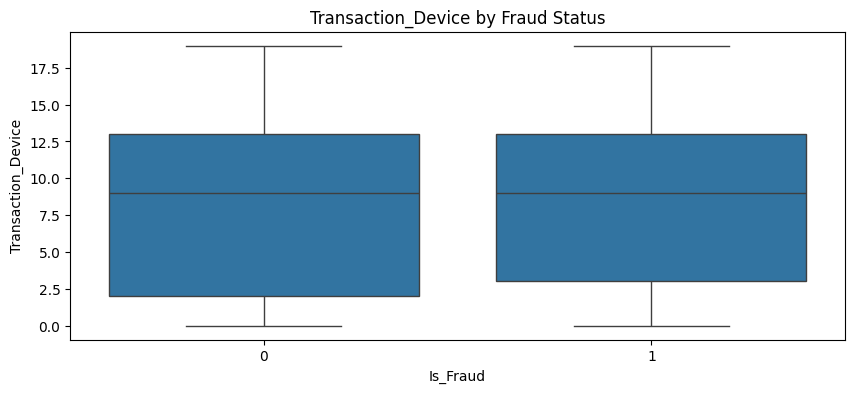

2026-06-09 21:23:28,317 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,333 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


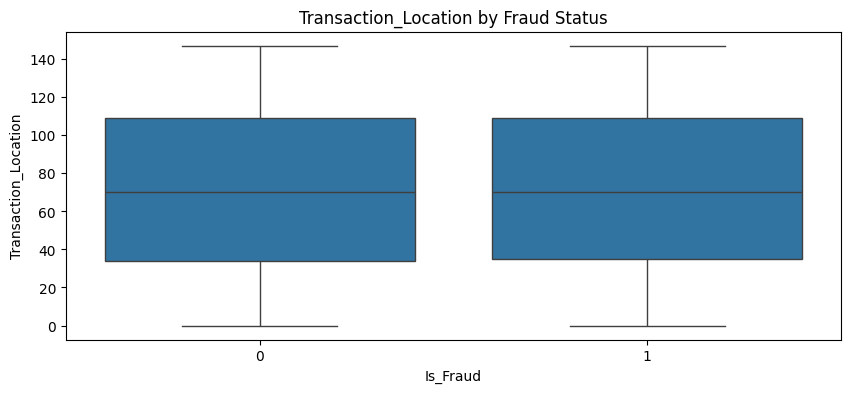

2026-06-09 21:23:28,483 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,499 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


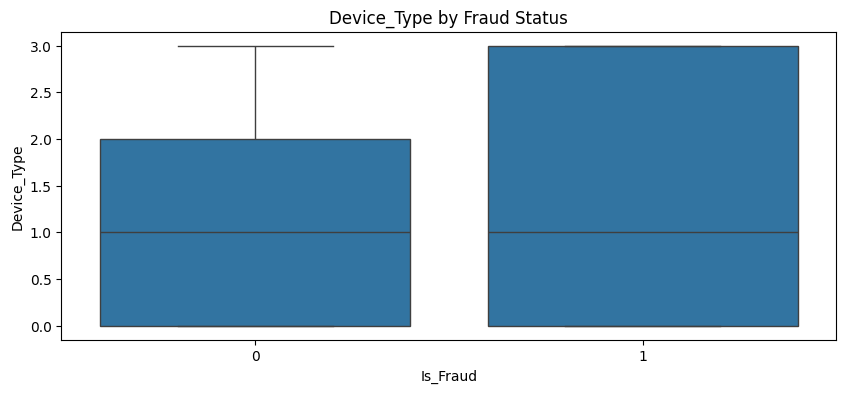

2026-06-09 21:23:28,632 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,661 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


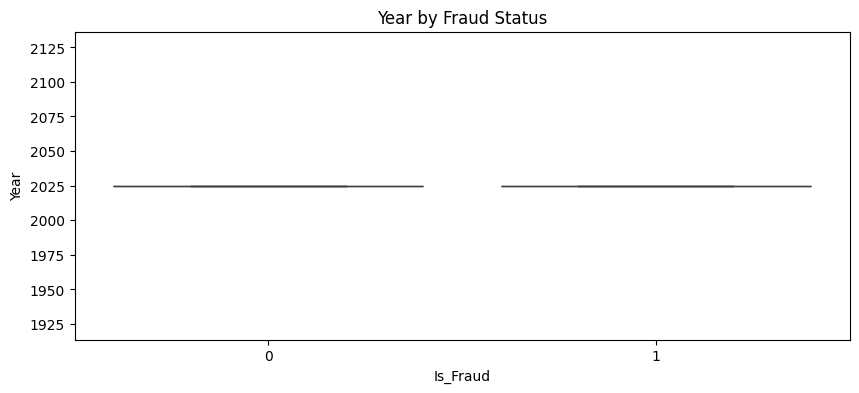

2026-06-09 21:23:28,812 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,827 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


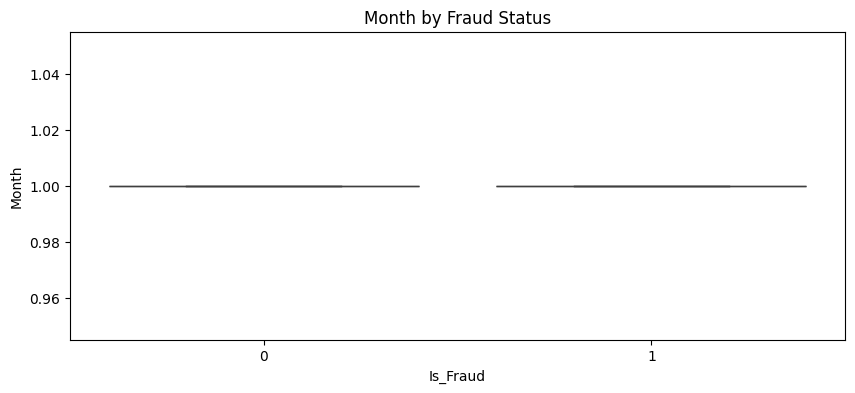

2026-06-09 21:23:28,961 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:28,985 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


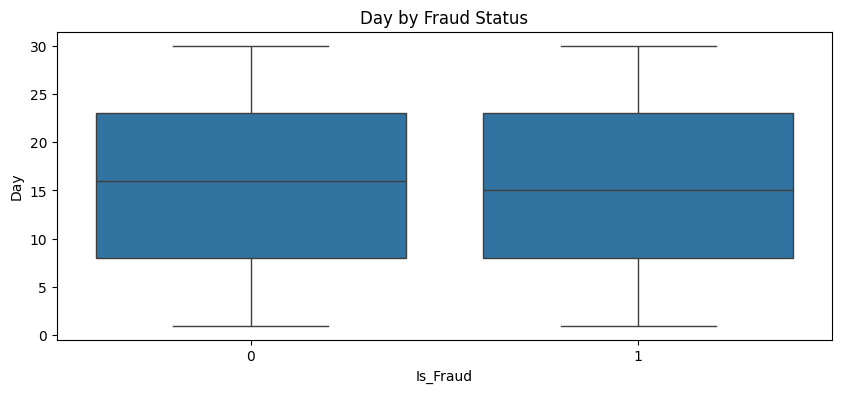

2026-06-09 21:23:29,123 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 21:23:29,151 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


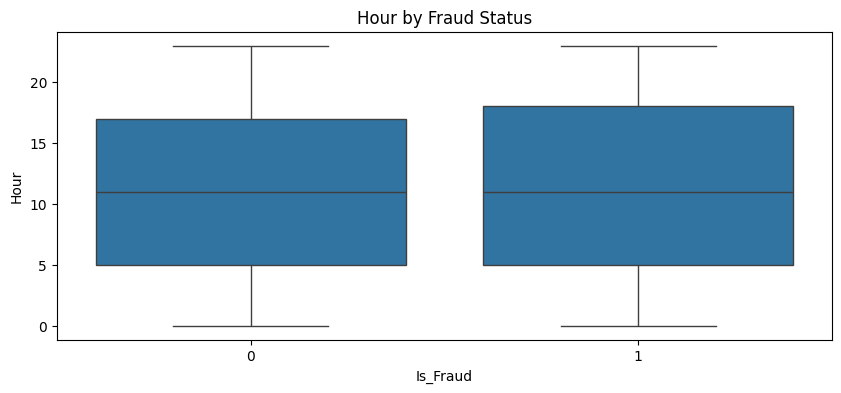

In [82]:
train_data = X_train.copy()
train_data['Is_Fraud'] = y_train

for col in X_train.columns:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        data=train_data,
        x='Is_Fraud',
        y=col
    )

    plt.title(f'{col} by Fraud Status')
    plt.show()

In [29]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

X_train= pt.fit_transform(X_train)
X_test= pt.transform(X_test)

In [31]:
X_train

array([[-0.04111417,  0.79374923, -0.35561707, ..., -0.20070774,
        -0.20220633, -0.20369561],
       [ 0.09536838,  0.9846    ,  1.15272968, ..., -0.20070774,
        -0.20220633, -0.20369561],
       [ 0.26158155, -0.00817006,  0.85233028, ..., -0.20070774,
        -0.20220633, -0.20369561],
       ...,
       [-1.53315666, -0.7103882 ,  0.16754119, ..., -0.20070774,
        -0.20220633, -0.20369561],
       [ 0.68918773,  0.31623714, -1.19448794, ..., -0.20070774,
        -0.20220633, -0.20369561],
       [ 0.16114324,  1.13285585,  0.23131848, ..., -0.20070774,
        -0.20220633, -0.20369561]], shape=(16140, 40))

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [171]:
X_train.shape

(16140, 40)

In [172]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="Shrutichauha7",
    repo_name="Fraud_Detection_Analysis",
    mlflow=True
)

mlflow.set_experiment("LogisticRegression Baseline")

with mlflow.start_run():
    mlflow.log_param("parameter name", "value")
    mlflow.log_metric("metric name", 1)

print("Run logged successfully")



Accessing as Shrutichauha7

Initialized MLflow to track repo "Shrutichauha7/Fraud_Detection_Analysis"

Repository Shrutichauha7/Fraud_Detection_Analysis initialized!

🏃 View run respected-goose-366 at: https://dagshub.com/Shrutichauha7/Fraud_Detection_Analysis.mlflow/#/experiments/2/runs/bbf6a5f93e994898a71bd1ed0fd3042b
🧪 View experiment at: https://dagshub.com/Shrutichauha7/Fraud_Detection_Analysis.mlflow/#/experiments/2
Run logged successfully


In [23]:
import mlflow
import logging
import os
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Starting MLflow run...")

with mlflow.start_run():

    start_time = time.time()

    try:
        
        logging.info("Logging Preprocessing Parameters")

        mlflow.log_param("model", "LogisticRegression")
        mlflow.log_param("test_size", 0.2)
        

        logging.info("Training model...")
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)


        logging.info("Making predictions...")
        y_pred = model.predict(X_test)

       
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

       
        logging.info("Logging metrics...")

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        logging.info("Saving model...")

        mlflow.sklearn.log_model(
            model,"model"
        )


        execution_time = time.time() - start_time

        mlflow.log_metric(
            "execution_time_seconds",
            execution_time
        )

        logging.info(f"Accuracy: {accuracy}")
        logging.info(f"Precision: {precision}")
        logging.info(f"Recall: {recall}")
        logging.info(f"F1 Score: {f1}")
        logging.info(f"ROC-AUC: {auc}")

        print("MLflow Run Completed Successfully!")

    except Exception as e:

        logging.error(f"Error occurred: {e}")

        mlflow.log_param("error", str(e))

        raise

2026-06-09 21:05:19,961 - INFO - Starting MLflow run...
2026-06-09 21:05:21,666 - INFO - Logging Preprocessing Parameters
2026-06-09 21:05:21,694 - INFO - Training model...
2026-06-09 21:05:21,714 - INFO - Making predictions...
2026-06-09 21:05:21,730 - INFO - Logging metrics...
2026-06-09 21:05:21,797 - INFO - Saving model...
2026/06/09 21:05:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 21:05:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026-06-09 21:05:30,491 - INFO - Accuracy: 0.5074331020812686
2026-06-09 21:05:30,494 - INFO - Precision: 0.5073891625615764
2026-06-09 21:05:30,494 - INFO - Recal

MLflow Run Completed Successfully!
